In [1]:
# Imports & setup
import pandas as pd
import numpy as np
import tmdbsimple as tmdb
import time, os, re
from dfply import *
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
# Load Data
horror_movies = pd.read_csv("C:/Personal Projects/horror_movies.csv")

In [3]:
# Quick exploration
horror_movies.head(10)
horror_movies.isna().sum()
horror_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55111 entries, 0 to 55110
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    55111 non-null  int64  
 1   title                 55111 non-null  object 
 2   release_date          55111 non-null  object 
 3   vote_average          55111 non-null  float64
 4   vote_count            55111 non-null  int64  
 5   budget                55111 non-null  int64  
 6   revenue               55111 non-null  int64  
 7   runtime               55111 non-null  int64  
 8   tagline               19649 non-null  object 
 9   adult                 55111 non-null  bool   
 10  production_companies  55111 non-null  object 
 11  countries             55111 non-null  object 
 12  language              55111 non-null  object 
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 5.1+ MB


In [4]:
# Data cleaning / formatting
horror_movies['title'] = horror_movies['title'].astype(str)
horror_movies['release_date'] = pd.to_datetime(horror_movies['release_date'], errors='coerce')
horror_movies['year'] = horror_movies['release_date'].dt.year
horror_movies['tagline'] = horror_movies['tagline'].astype(str)
horror_movies['countries'] = horror_movies['countries'].str.extract(r"\['(.+?)'\]")

horror_movies['production_companies'] = (
    horror_movies['production_companies']
    .str.extract(r"\[(.*)\]")[0]
    .str.replace("'", "", regex=False)
    .str.split(", ")
)

horror_movies.head()


horror_movies['release_date'] = pd.to_datetime(horror_movies['release_date'], errors='coerce')

horror_movies['year'] = horror_movies['release_date'].dt.year

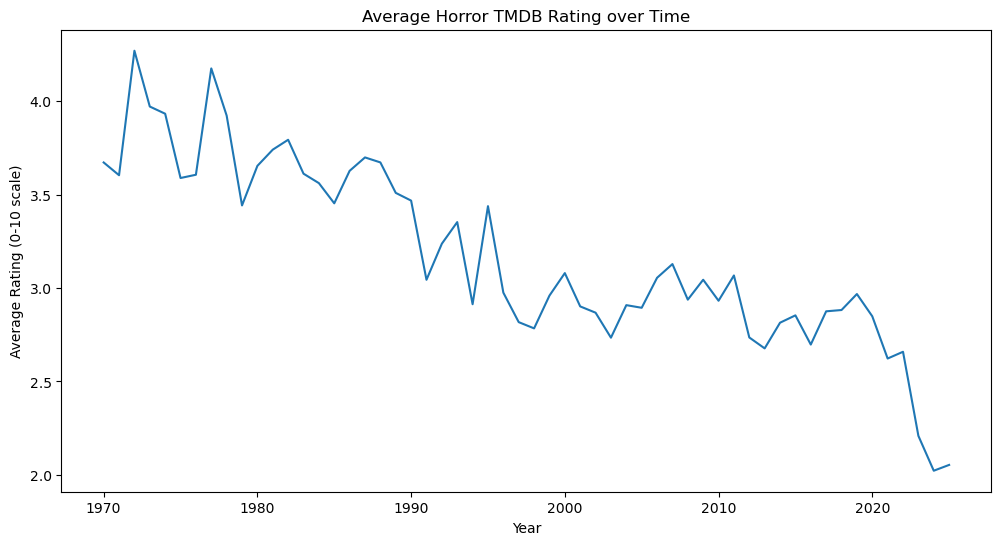

In [5]:
# Ratings over time
horror_ratings_by_year = horror_movies.groupby('year')['vote_average'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_ratings_by_year.index, horror_ratings_by_year.values)
plt.title('Average Horror TMDB Rating over Time')
plt.xlabel('Year')
plt.ylabel('Average Rating (0-10 scale)')
plt.show()

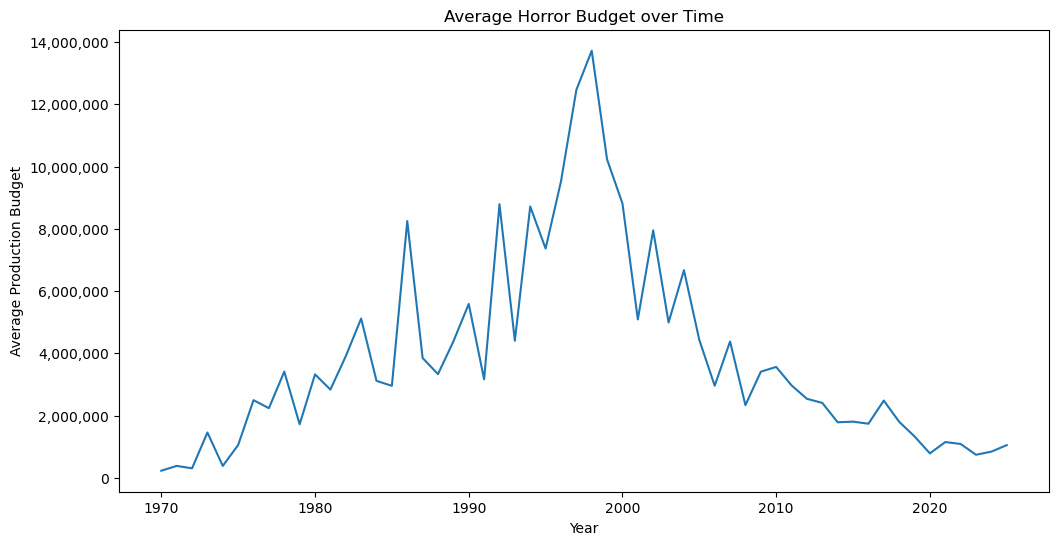

In [6]:
# Budgets over time
horror_with_budget = horror_movies[horror_movies['budget'] > 0]
horror_budgets_by_year = horror_with_budget.groupby('year')['budget'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_budgets_by_year.index, horror_budgets_by_year.values)
plt.title('Average Horror Budget over Time')
plt.xlabel('Year')
plt.ylabel('Average Production Budget')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

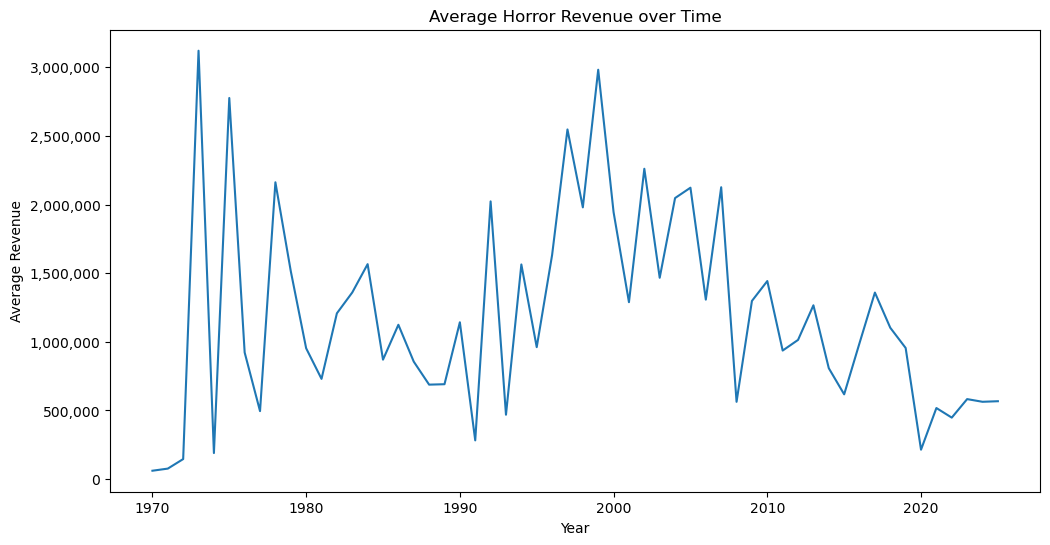

In [7]:
#Revenue over Time
horror_revenues_by_year = horror_movies.groupby('year')['revenue'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_revenues_by_year.index, horror_revenues_by_year.values)
plt.title('Average Horror Revenue over Time')
plt.xlabel('Year')
plt.ylabel('Average Revenue')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) 
plt.show()

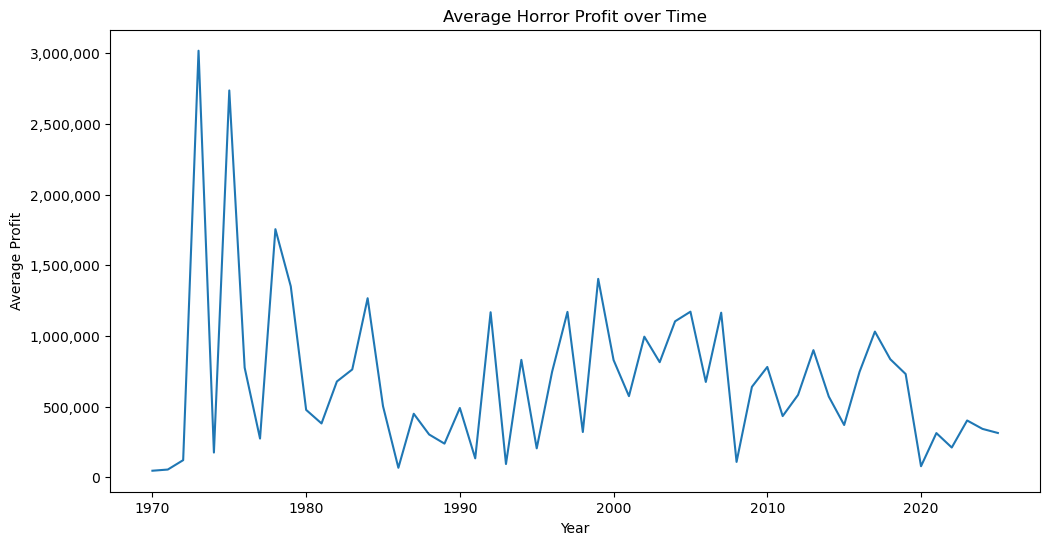

In [8]:
#Profit by Year
horror_movies['profit'] = horror_movies['revenue'] - horror_movies['budget']
horror_profits_by_year = horror_movies.groupby('year')['profit'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_profits_by_year.index, horror_profits_by_year.values)
plt.title('Average Horror Profit over Time')
plt.xlabel('Year')
plt.ylabel('Average Profit')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) 
plt.show()

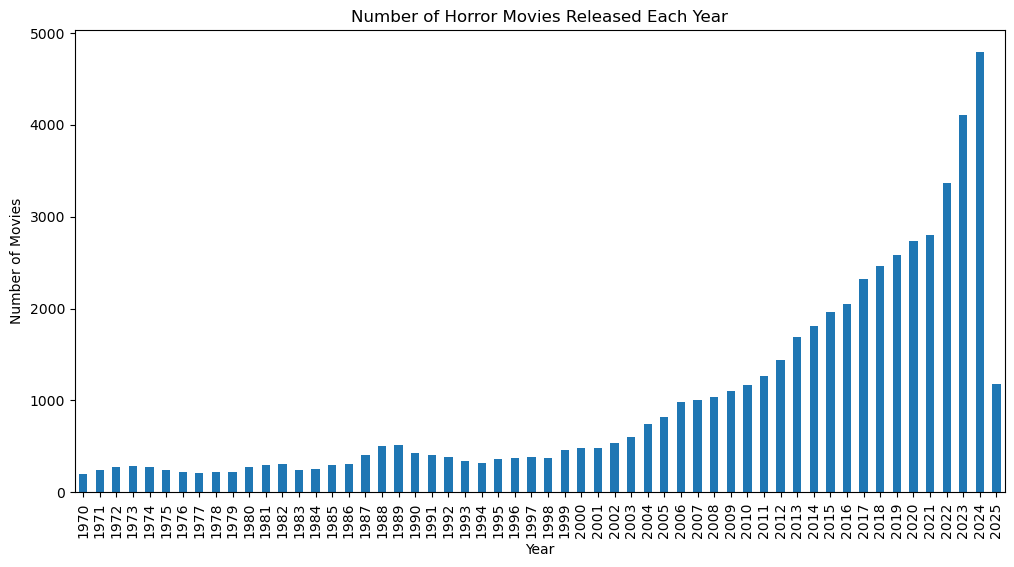

In [9]:
#Movies Each Year
horror_movies['release_date'].dt.year.value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.title('Number of Horror Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

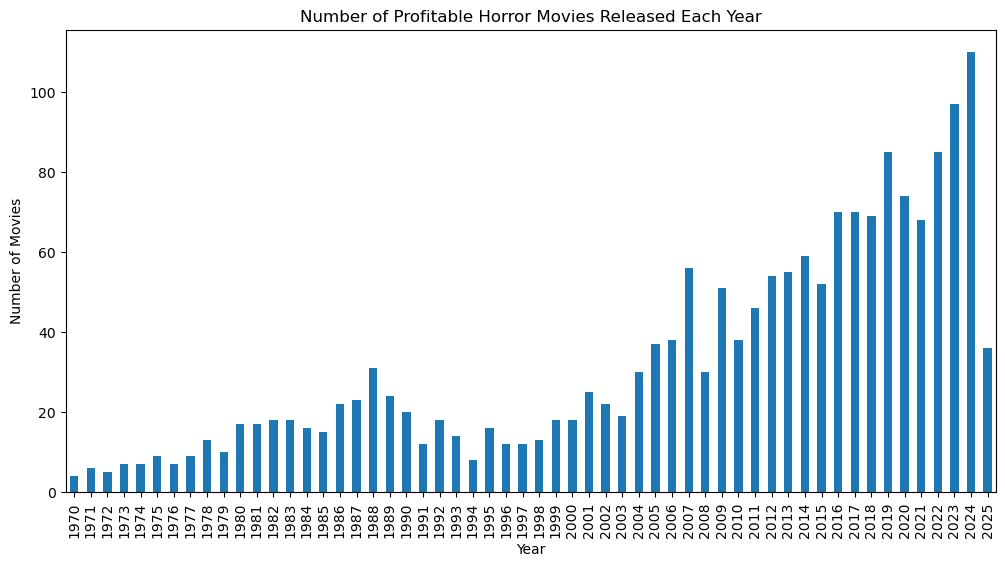

In [10]:
#Profitable Movies each Year
profitable_horror_movies = horror_movies[horror_movies['profit'] > 0]
profitable_horror_movies['release_date'].dt.year.value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.title('Number of Profitable Horror Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

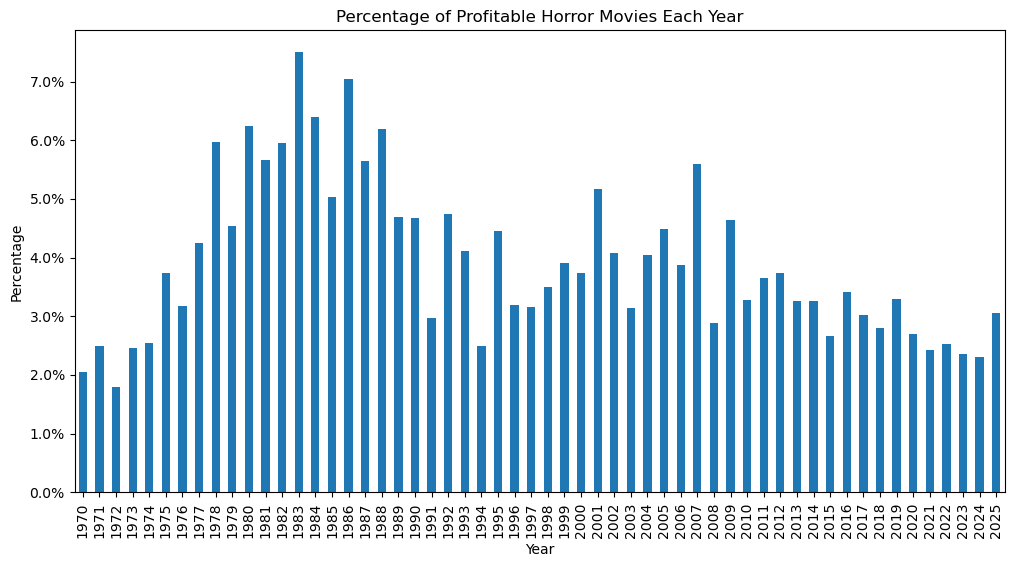

In [11]:
#Percentage of Profitable Movies Each Year
profitable_horror_movies['release_date'].dt.year.value_counts().sort_index() / horror_movies['release_date'].dt.year.value_counts().sort_index() * 100
(100 * profitable_horror_movies['release_date'].dt.year.value_counts().sort_index() / horror_movies['release_date'].dt.year.value_counts().sort_index()).plot(kind='bar', figsize=(12,6))
plt.title('Percentage of Profitable Horror Movies Each Year')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
plt.show()

                         22566
Amumo 98                   199
Regal Entertainment        158
Brain Damage Films         151
W.A.V.E. Productions       135
The Asylum                 131
Nikkatsu Corporation       125
Universal Pictures         117
Ltd.                       103
Blumhouse Productions       98
Name: production_companies, dtype: int64


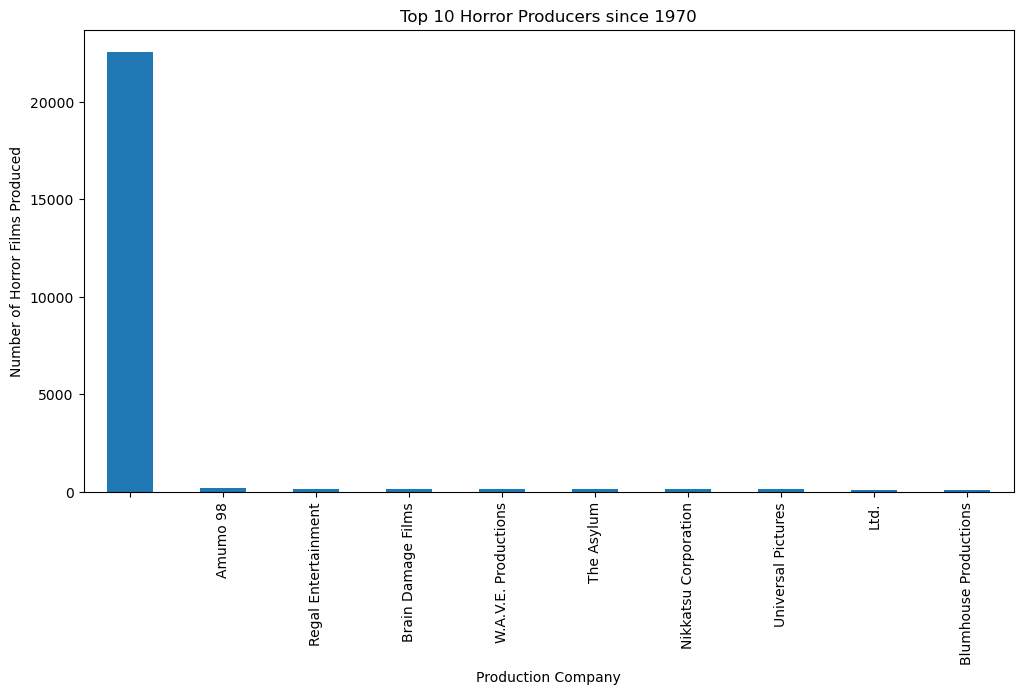

In [12]:
# Production companies
all_production_companies = horror_movies['production_companies'].explode()
top_10_horror_producers = all_production_companies.value_counts().head(10)
print(top_10_horror_producers)

Horror_movies_by_production_company = all_production_companies.value_counts()
Horror_movies_by_company_bar_plot = Horror_movies_by_production_company.head(10).plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Horror Producers since 1970')
plt.xlabel('Production Company')
plt.ylabel('Number of Horror Films Produced')
plt.show()

        production_companies  vote_average  movie_count
22550    Soprano Productions      9.153659           41
27379                 dentsu      6.222935           31
26424  Warner Bros. Pictures      6.193081           62
4305        CJ Entertainment      6.068524           42
25964  Vertigo Entertainment      6.043536           28
23715                   TOHO      5.983727           66
25613     Universal Pictures      5.982034          117
18410     Paramount Pictures      5.939551           69
14021        Legacy Pictures      5.881900           30
5654       Columbia Pictures      5.880093           54


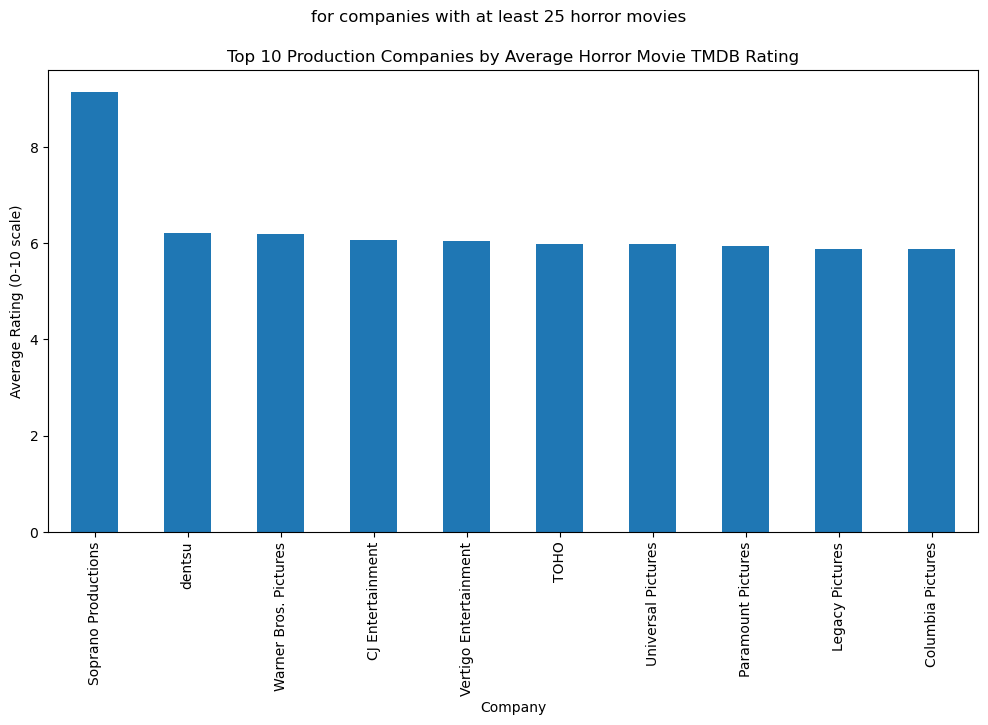

In [13]:
# Ratings by production company
horror_movies_exploded = horror_movies.explode('production_companies')
average_rating_by_company = (
    horror_movies_exploded
    .groupby('production_companies')
    .agg({'vote_average': 'mean', 'title': 'count'})
    .rename(columns={'title': 'movie_count'})
    .reset_index()
)

average_rating_by_company_filtered = average_rating_by_company[average_rating_by_company['movie_count'] >= 25]
top_10_companies_by_rating = average_rating_by_company_filtered.sort_values(by='vote_average', ascending=False).head(10)
print(top_10_companies_by_rating)

top_10_companies_by_rating.set_index('production_companies')['vote_average'].plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Production Companies by Average Horror Movie TMDB Rating')
plt.suptitle('for companies with at least 25 horror movies')
plt.xlabel('Company')
plt.ylabel('Average Rating (0-10 scale)')
plt.show()

In [14]:
# Replace 0s with NaN in the specified columns
horror_movies[['vote_average','vote_count', 'budget', 'revenue', 'runtime', ]] = horror_movies[['vote_average','vote_count', 'budget', 'revenue', 'runtime', ]].replace(0, np.nan)

# Then drop rows with NA in these key columns (if you want a cleaned dataset)
horror_movies_cleaned_all = horror_movies.dropna(subset=['vote_count', 'budget', 'revenue', 'vote_average', 'runtime'])

horror_movies_cleaned_votes = horror_movies.dropna(subset=['vote_count'])

horror_movies_cleaned_budget = horror_movies.dropna(subset=['budget'])

horror_movies_cleaned_runtime = horror_movies.dropna(subset=['runtime'])

In [15]:
#Correlation analysis cleaned runtime

horror_cleaned_runtime_correlation_matrix = horror_movies_cleaned_runtime[['vote_average', 'vote_count', 'budget', 'revenue', 'profit', 'runtime']].corr()

horror_cleaned_runtime_correlation_matrix.style.background_gradient(cmap='coolwarm')

#There's a moderately high positive correlation between vote count and revenue
#as well as vote count and budget. There's also a very high positive
#correlation between revenue and profit, which is expected.
#budget also has a moderate positive correlation with vote count and revenue.
#It looks like there's a negative correlation between runtime and
#vote average (but it's weak)

,vote_average,vote_count,budget,revenue,profit,runtime
vote_average,1.000000,0.099448,0.069345,0.137114,0.061457,-0.259348
vote_count,0.099448,1.000000,0.517410,0.746788,0.727457,0.135453
budget,0.069345,0.517410,1.000000,0.597918,0.400204,0.285613
revenue,0.137114,0.746788,0.597918,1.000000,0.962711,0.221050
profit,0.061457,0.727457,0.400204,0.962711,1.000000,0.070104
runtime,-0.259348,0.135453,0.285613,0.221050,0.070104,1.000000


In [16]:
##Create a "Classic Horror" comparative dataframe:
classic_horror_movies = [
    "The Exorcist",
    "Halloween",
    "A Nightmare on Elm Street",
    "Friday the 13th",
    "The Texas Chain Saw Massacre",
    "The Thing",
    "The Blair Witch Project",
    "The Shining",
    "Alien",
    "Jaws",
    "Scream"
]
#We also need to grab the year of release for each of these so we don't get duplicates/sequels

classic_horror_movie_years = {
    "The Exorcist": 1973,
    "Halloween": 1978,
    "A Nightmare on Elm Street": 1984,
    "Friday the 13th": 1980,
    "The Texas Chain Saw Massacre": 1974,
    "The Thing": 1982,
    "The Blair Witch Project": 1999,
    "The Shining": 1980,
    "Alien": 1979,
    "Jaws": 1975,
    "Scream": 1996
}

classic_horror = pd.DataFrame({
    'title': classic_horror_movies,
    'year': [classic_horror_movie_years[title] for title in classic_horror_movies]
})

#Then we need to filter this from the main horror movies data frame to create a subset:

classic_horror_df = pd.merge(
    classic_horror,
    horror_movies,
    on=['title', 'year'],
    how='inner'
)




In [17]:
# Now that we have the classic horror movies, let's compare their average metrics
# to the overall averages for horror movies

overall_average_df = pd.DataFrame({
    'Metric': ['vote_average', 
               'vote_count', 
               'budget', 
               'revenue'],
    'Overall Average': [
        horror_movies['vote_average'].mean(),
        horror_movies['vote_count'].mean(),
        horror_movies['budget'].mean(),
        horror_movies['revenue'].mean(),
    ]   
})
classic_horror_averages = {
    'Metric': ['vote_average', 
               'vote_count', 
               'budget', 
               'revenue',],
    'Classic Horror Average': [
        classic_horror_df['vote_average'].mean(),
        classic_horror_df['vote_count'].mean(),
        classic_horror_df['budget'].mean(),
        classic_horror_df['revenue'].mean(),
    ]
}
classic_horror_average_df = pd.DataFrame(classic_horror_averages)

comparison_df = pd.merge(overall_average_df, classic_horror_average_df, on='Metric')

comparison_df['Difference'] = comparison_df['Classic Horror Average'] - comparison_df['Overall Average']

comparison_df['Percent Difference'] = (comparison_df['Difference'] / comparison_df['Overall Average']) * 100

comparison_df.style.format({
    'Overall Average': '{:,.2f}',
    'Classic Horror Average': '{:,.2f}',
    'Difference': '{:,.2f}',
    'Percent Difference': '{:,.2f}%',
})

comparison_df

,Metric,Overall Average,Classic Horror Average,Difference,Percent Difference
0,vote_average,5.182285e+00,7.496000e+00,2.313715e+00,44.646609
1,vote_count,9.702171e+01,8.177769e+03,8.080748e+03,8328.803870
2,budget,2.275894e+06,8.221154e+06,5.945260e+06,261.227528
3,revenue,2.142578e+07,1.796354e+08,1.582097e+08,738.407963


In [20]:
## Looking at horror movies with an emphasis on inflation adjusted metrics

adjusted_horror_movies = horror_movies.copy()

#We are assuming 3% inflation across the board for all years

adjusted_horror_movies['Adjusted Budget'] = adjusted_horror_movies['budget'] + (adjusted_horror_movies['budget'] * 0.03 * (2024 - adjusted_horror_movies['year']))

adjusted_horror_movies['Adjusted Revenue'] = adjusted_horror_movies['revenue'] + (adjusted_horror_movies['revenue'] * 0.03 * (2024 - adjusted_horror_movies['year']))

adjusted_horror_movies['Adjusted Profit'] = adjusted_horror_movies['Adjusted Revenue'] - adjusted_horror_movies['Adjusted Budget']

adjusted_horror_movies.head(5)





,id,title,release_date,vote_average,vote_count,budget,revenue,runtime,tagline,adult,production_companies,countries,language,year,profit,Adjusted Budget,Adjusted Revenue,Adjusted Profit
0,575186,The Companions of Baal,1970-06-11,7.0,1.0,NaN,NaN,350.0,nan,False,[ORTF],France,fr,1970,0,NaN,NaN,NaN
1,1369909,Kaun Ho Tum,1970-01-01,NaN,NaN,NaN,NaN,NaN,nan,False,[Suresh Pictures],India,hi,1970,0,NaN,NaN,NaN
2,1309191,The Raven,1970-01-01,NaN,NaN,NaN,NaN,5.0,nan,False,[Busam & Krummen Productions],United States of America,en,1970,0,NaN,NaN,NaN
3,1287090,Monkey on Their Backs,1970-01-01,NaN,NaN,NaN,NaN,1.0,Why do you think they call it DOPE?,False,[National Clearinghouse for Alcohol and Drug A...,NaN,en,1970,0,NaN,NaN,NaN
4,1260195,Zombie Door,1970-01-01,NaN,NaN,NaN,NaN,1.0,nan,False,[],United States of America,en,1970,0,NaN,NaN,NaN


In [21]:
# Replace 0s with NaN in the specified columns
adjusted_horror_movies[['vote_average','vote_count', 'budget', 'revenue', 'runtime', ]] = adjusted_horror_movies[['vote_average','vote_count', 'budget', 'revenue', 'runtime', ]].replace(0, np.nan)

# Then drop rows with NA in these key columns (if you want a cleaned dataset)
adjusted_horror_movies_cleaned_all = adjusted_horror_movies.dropna(subset=['vote_count', 'budget', 'revenue', 'vote_average', 'runtime'])

adjusted_horror_movies_cleaned_votes = adjusted_horror_movies.dropna(subset=['vote_count'])

adjusted_horror_movies_cleaned_budget = adjusted_horror_movies.dropna(subset=['budget'])

adjusted_horror_movies_cleaned_runtime = adjusted_horror_movies.dropna(subset=['runtime'])

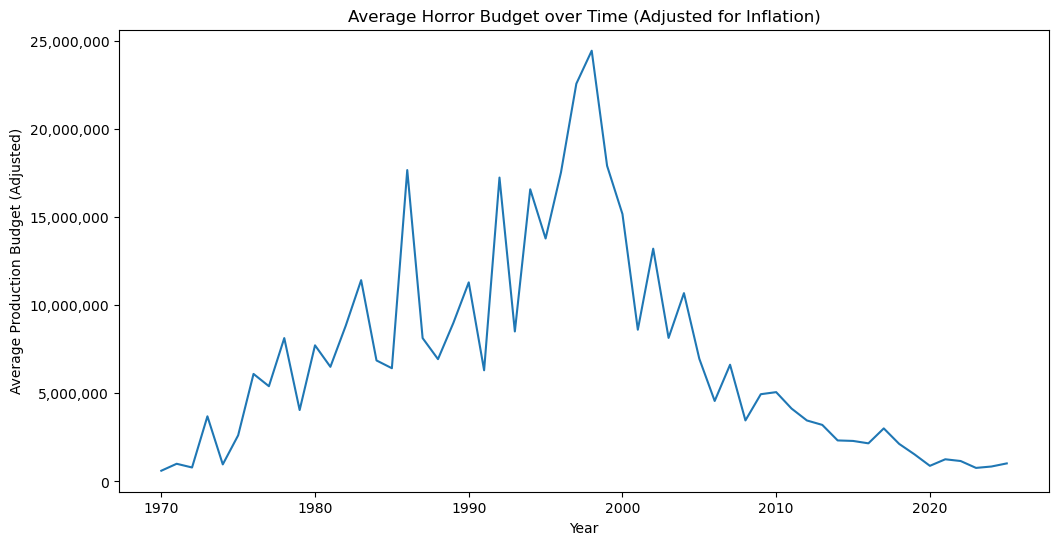

In [22]:
#Horror Movie Budgets over time (adjusted for inflation)

horror_budgets_by_year_adjusted = adjusted_horror_movies_cleaned_budget.groupby('year')['Adjusted Budget'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_budgets_by_year_adjusted.index, horror_budgets_by_year_adjusted.values)
plt.title('Average Horror Budget over Time (Adjusted for Inflation)')
plt.xlabel('Year')
plt.ylabel('Average Production Budget (Adjusted)')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

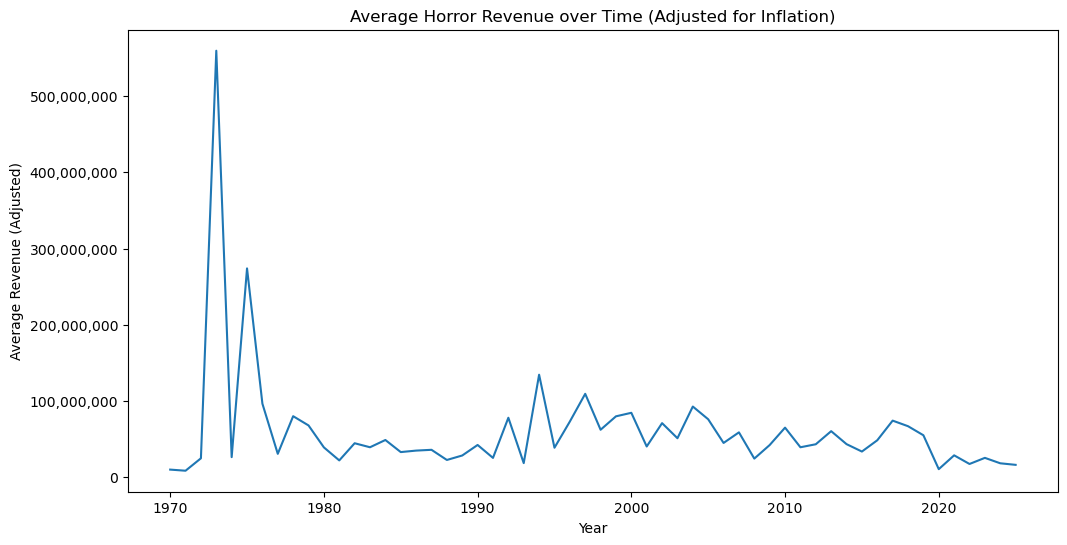

In [24]:
#Horror movie Revenues over time (adjusted for inflation)

horror_revenues_by_year_adjusted = adjusted_horror_movies_cleaned_budget.groupby('year')['Adjusted Revenue'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_revenues_by_year_adjusted.index, horror_revenues_by_year_adjusted.values)
plt.title('Average Horror Revenue over Time (Adjusted for Inflation)')
plt.xlabel('Year')
plt.ylabel('Average Revenue (Adjusted)')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()

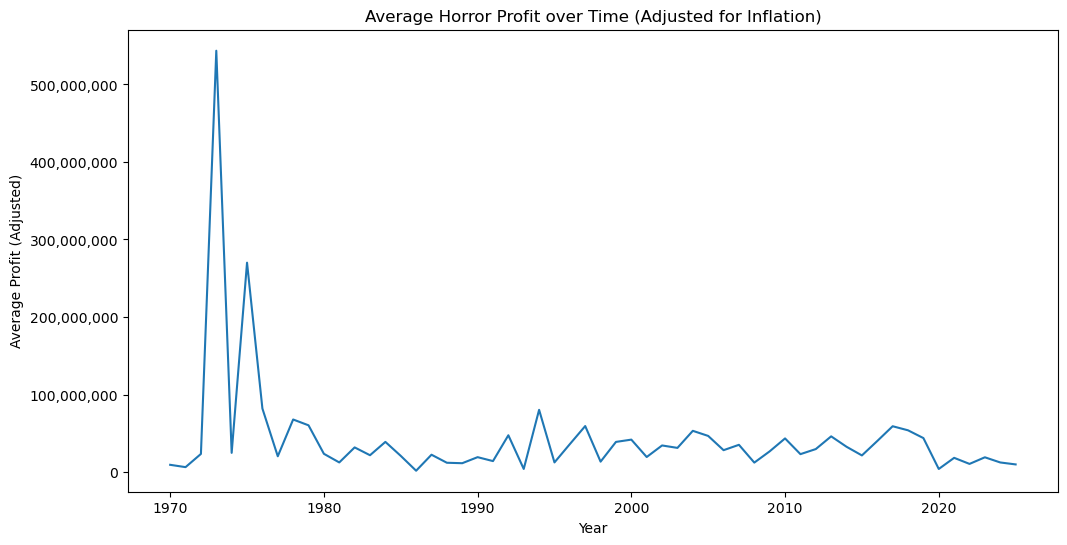

In [25]:
#Horror movie profits over time (adjusted for inflation)

horror_profits_by_year_adjusted = adjusted_horror_movies_cleaned_budget.groupby('year')['Adjusted Profit'].mean()
plt.figure(figsize=(12,6))
plt.plot(horror_profits_by_year_adjusted.index, horror_profits_by_year_adjusted.values)
plt.title('Average Horror Profit over Time (Adjusted for Inflation)')
plt.xlabel('Year')
plt.ylabel('Average Profit (Adjusted)')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.show()